# Đồ án: Phân tích xu hướng kết hôn của giới trẻ Việt Nam (18–35)

## Mục tiêu
- Áp dụng **Cây quyết định (Decision Tree)** và **Naive Bayes** để dự báo `marital_class`
- Dữ liệu: Synthetic microdata ≥3000 cá nhân, tham số hóa theo GSO/UNFPA 2019
- Biến target: `marital_class` (0: chưa kết hôn, 1: đã/đang kết hôn)

## Nội dung
1. Cài đặt và kiểm tra môi trường
2. Sinh dữ liệu synthetic
3. Khám phá dữ liệu (EDA)
4. Tiền xử lý dữ liệu
5. Mô hình Decision Tree
6. Mô hình Naive Bayes
7. Đánh giá và so sánh
8. Dự đoán cho Personas

## 1. Cài đặt và kiểm tra môi trường

In [1]:
# Kiểm tra phiên bản Python
import sys
print(f"Python version: {sys.version}")

# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, RocCurveDisplay,
    classification_report
)

# Kiểm tra phiên bản thư viện
print(f"\nNumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
import sklearn
print(f"Scikit-learn version: {sklearn.__version__}")

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("\nTất cả thư viện đã được import thành công!")

Python version: 3.9.22 | packaged by conda-forge | (main, Apr 14 2025, 23:36:04) 
[Clang 18.1.8 ]

NumPy version: 2.0.2
Pandas version: 2.3.1
Scikit-learn version: 1.6.1

Tất cả thư viện đã được import thành công!


## 2. Sinh dữ liệu Synthetic

Tham số hóa theo thông tin GSO/UNFPA 2019:
- **TFR toàn quốc**: 2,09 (đô thị 1,83; nông thôn 2,26)
- **Phân bố vùng**: Bắc 45%, Trung 20%, Nam 35%
- **Đô thị hóa**: ~44%
- **Học vấn cao** → mức sinh/kết hôn muộn hơn

In [2]:
# Sinh dữ liệu synthetic
np.random.seed(2026)
N = 3000

# 1) Khung dữ liệu danh mục
age = np.random.randint(18, 36, N)
sex = np.random.choice(["Nam", "Nữ"], N, p=[0.49, 0.51])
region = np.random.choice(["Bắc", "Trung", "Nam"], N, p=[0.45, 0.20, 0.35])
urban_rural = np.random.choice(["Đô thị", "Nông thôn"], N, p=[0.44, 0.56])
education = np.random.choice(["≤THPT", "CĐ", "ĐH", ">ĐH"], N, p=[0.48, 0.20, 0.28, 0.04])

df = pd.DataFrame({
    "age": age,
    "sex": sex,
    "region": region,
    "urban_rural": urban_rural,
    "education": education
})

# 2) Thu nhập lognormal
base = np.random.lognormal(mean=8.05, sigma=0.55, size=N)
edu_mult = df["education"].map({"≤THPT": 0.85, "CĐ": 1.0, "ĐH": 1.18, ">ĐH": 1.35})
urb_mult = np.where(df["urban_rural"] == "Đô thị", 1.10, 0.95)
df["income_pc"] = base * edu_mult * urb_mult

# 3) age_group & income_level
df["age_group"] = pd.cut(df["age"], bins=[17, 24, 29, 35],
                          labels=["18-24", "25-29", "30-35"], include_lowest=True)
q33, q66 = df["income_pc"].quantile([0.33, 0.66])
df["income_level"] = df["income_pc"].apply(
    lambda x: "low" if x < q33 else ("mid" if x < q66 else "high")
)

# 4) Xác suất logistic tham số hóa
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logit_married(r):
    base = -2.2 + {"18-24": -0.6, "25-29": 0.6, "30-35": 1.0}[r.age_group]
    base += -0.25 if r.urban_rural == "Đô thị" else 0.25
    base += {"≤THPT": 0.25, "CĐ": 0.05, "ĐH": -0.20, ">ĐH": -0.35}[r.education]
    base += -0.20 if r.region == "Nam" else (0.05 if r.region == "Bắc" else 0.0)
    return base

def logit_child(r):
    base = -2.8 + {"18-24": -0.7, "25-29": 0.6, "30-35": 1.2}[r.age_group]
    base += -0.35 if r.urban_rural == "Đô thị" else 0.35
    base += {"≤THPT": 0.30, "CĐ": 0.05, "ĐH": -0.25, ">ĐH": -0.40}[r.education]
    base += -0.15 if r.region == "Nam" else (0.05 if r.region == "Bắc" else 0.0)
    return base

p_married = df.apply(logit_married, axis=1).pipe(sigmoid)
p_child = df.apply(logit_child, axis=1).pipe(sigmoid)
df["marital_class"] = (np.random.rand(N) < p_married).astype(int)
df["has_child"] = (np.random.rand(N) < p_child).astype(int)

# 5) Chọn cột kết quả
df = df[["age", "age_group", "sex", "region", "urban_rural", "education",
         "income_pc", "income_level", "has_child", "marital_class"]]

print(f"Kích thước dữ liệu: {df.shape}")
print(f"\nPhân phối target (marital_class):")
print(df["marital_class"].value_counts())
print(f"\nTỷ lệ kết hôn: {df['marital_class'].mean():.2%}")

df.head(10)

Kích thước dữ liệu: (3000, 10)

Phân phối target (marital_class):
marital_class
0    2491
1     509
Name: count, dtype: int64

Tỷ lệ kết hôn: 16.97%


,age,age_group,sex,region,urban_rural,education,income_pc,income_level,has_child,marital_class
0,19,18-24,Nữ,Bắc,Nông thôn,≤THPT,2249.485142,low,0,0
1,24,18-24,Nữ,Bắc,Nông thôn,≤THPT,3769.524868,mid,0,0
2,31,30-35,Nữ,Nam,Đô thị,ĐH,1886.117974,low,0,0
3,31,30-35,Nữ,Bắc,Đô thị,≤THPT,6487.233940,high,0,0
4,23,18-24,Nữ,Nam,Đô thị,ĐH,2108.838233,low,0,0
5,30,30-35,Nam,Nam,Đô thị,≤THPT,4288.187093,high,0,1
6,20,18-24,Nữ,Trung,Nông thôn,ĐH,4366.469927,high,0,1
7,31,30-35,Nữ,Bắc,Đô thị,≤THPT,5580.826092,high,0,0
8,18,18-24,Nam,Nam,Nông thôn,>ĐH,2168.391442,low,0,0
9,25,25-29,Nam,Nam,Đô thị,CĐ,1836.714101,low,0,1


## 3. Khám phá dữ liệu (EDA)

THỐNG KÊ MÔ TẢ
               age     income_pc   has_child  marital_class
count  3000.000000   3000.000000  3000.00000    3000.000000
mean     26.349000   3707.091443     0.10300       0.169667
std       5.187951   2306.168289     0.30401       0.375402
min      18.000000    394.305714     0.00000       0.000000
25%      22.000000   2135.654838     0.00000       0.000000
50%      26.000000   3158.557988     0.00000       0.000000
75%      31.000000   4640.740996     0.00000       0.000000
max      35.000000  26560.456280     1.00000       1.000000


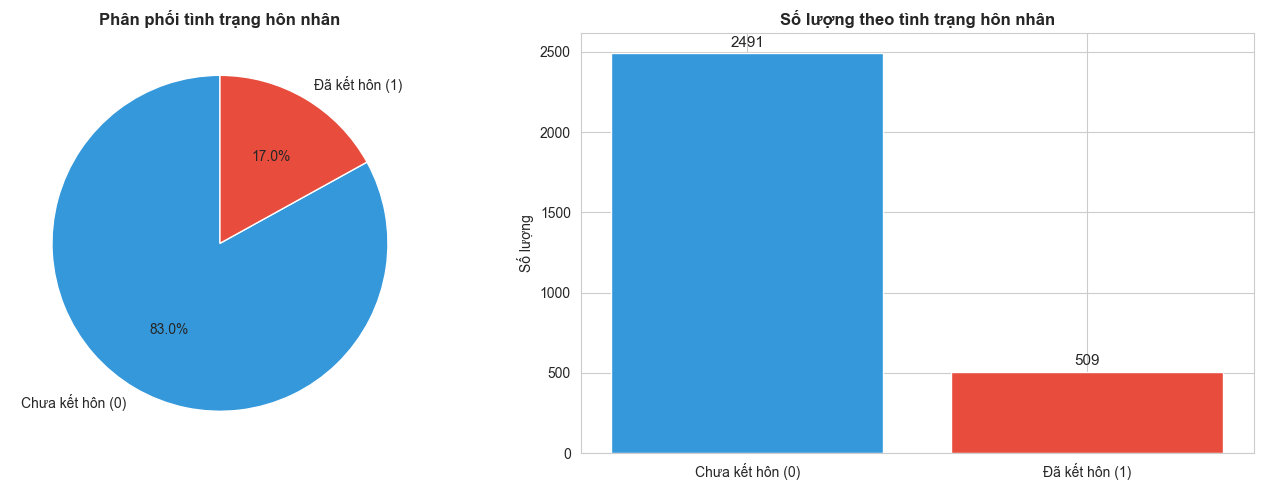

In [3]:
# Thống kê mô tả
print("="*60)
print("THỐNG KÊ MÔ TẢ")
print("="*60)
print(df.describe())

# Biểu đồ phân phối target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
ax1 = axes[0]
counts = df["marital_class"].value_counts()
labels = ["Chưa kết hôn (0)", "Đã kết hôn (1)"]
colors = ["#3498db", "#e74c3c"]
ax1.pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title("Phân phối tình trạng hôn nhân", fontsize=12, fontweight='bold')

# Bar chart
ax2 = axes[1]
bars = ax2.bar(labels, counts.values, color=colors, edgecolor='white')
for bar, count in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{count}', ha='center', va='bottom', fontsize=11)
ax2.set_title("Số lượng theo tình trạng hôn nhân", fontsize=12, fontweight='bold')
ax2.set_ylabel("Số lượng")

plt.tight_layout()
plt.show()

/var/folders/1f/rj6sgdwn1mj6zfg7vv_f6md40000gn/T/ipykernel_95507/386742502.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  marriage_rate = df.groupby(col)["marital_class"].mean() * 100


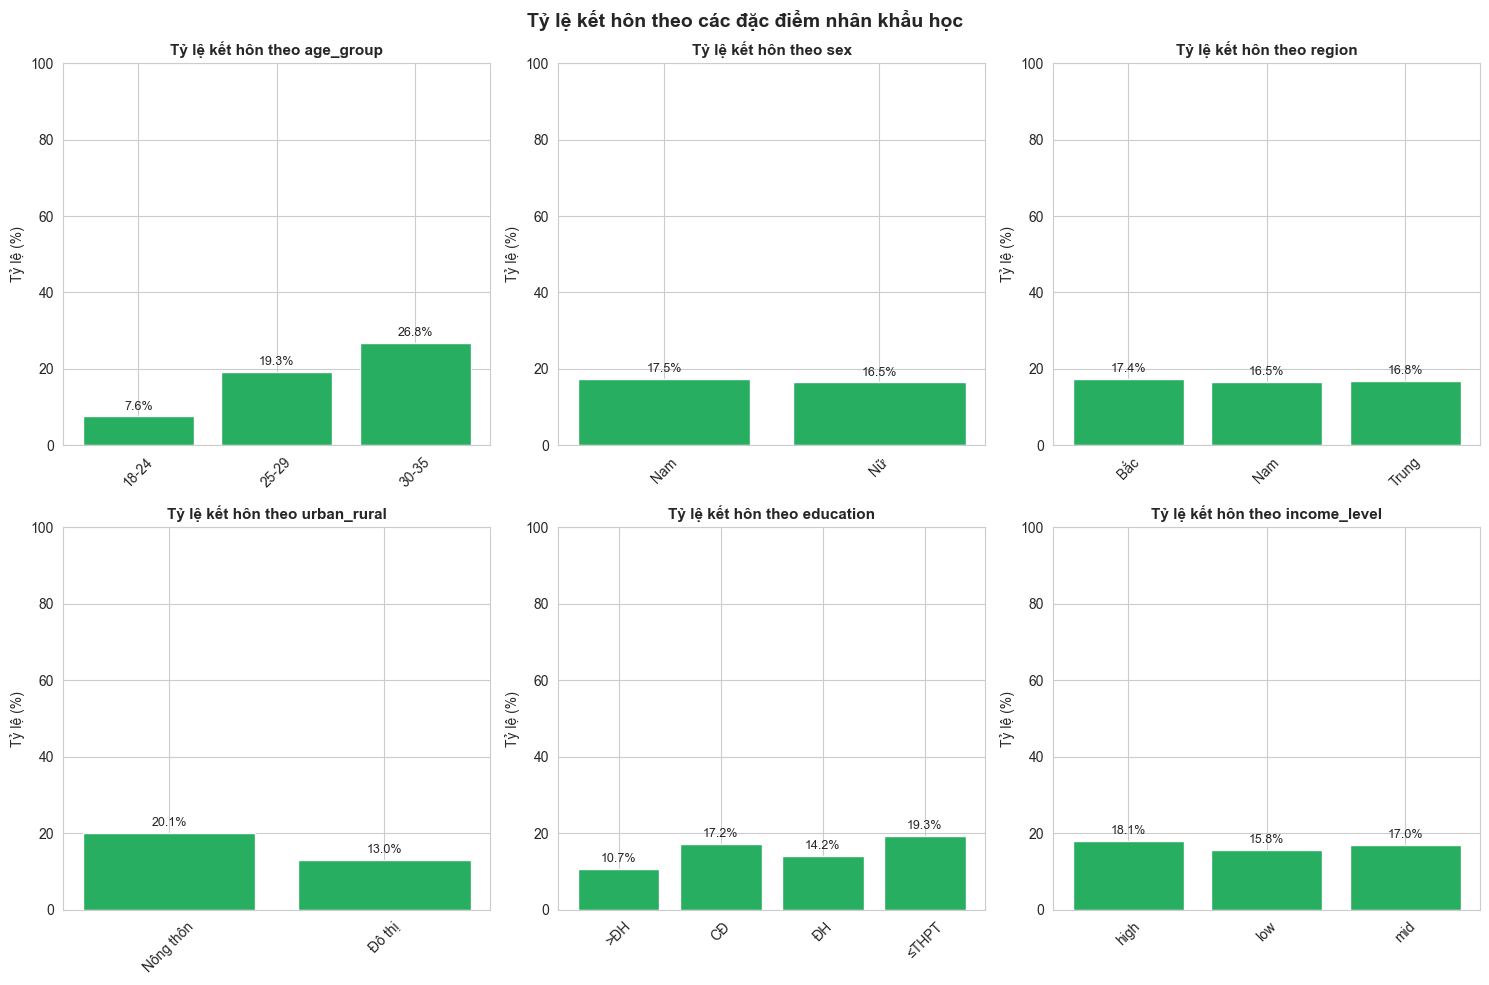

In [4]:
# Tỷ lệ kết hôn theo các đặc điểm
categorical_cols = ["age_group", "sex", "region", "urban_rural", "education", "income_level"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    marriage_rate = df.groupby(col)["marital_class"].mean() * 100
    bars = ax.bar(marriage_rate.index, marriage_rate.values, color='#27ae60', edgecolor='white')
    
    for bar, rate in zip(bars, marriage_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)
    
    ax.set_title(f"Tỷ lệ kết hôn theo {col}", fontsize=11, fontweight='bold')
    ax.set_ylabel("Tỷ lệ (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Tỷ lệ kết hôn theo các đặc điểm nhân khẩu học", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Tiền xử lý và chia dữ liệu

- **Mã hóa cho Decision Tree**: One-Hot Encoding (OHE)
- **Mã hóa cho Naive Bayes**: Ordinal Encoding
- **Chia dữ liệu**: Train/Test = 75/25, stratify theo target

In [5]:
# Định nghĩa features và target
FEATURES = ["age_group", "sex", "region", "urban_rural", "education", "income_level", "has_child"]
TARGET = "marital_class"

# Chia dữ liệu
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=2026
)

print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTrain target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

# Tạo preprocessor cho Decision Tree (One-Hot Encoding)
pre_tree = ColumnTransformer([
    ("ohe", OneHotEncoder(handle_unknown="ignore"), FEATURES)
], remainder="drop")

# Tạo preprocessor cho Naive Bayes (Ordinal Encoding)
pre_nb = ColumnTransformer([
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), FEATURES)
], remainder="drop")

print("\nPreprocessors đã được tạo!")

Train set: 2250 samples
Test set: 750 samples

Train target distribution:
marital_class
0    1868
1     382
Name: count, dtype: int64

Test target distribution:
marital_class
0    623
1    127
Name: count, dtype: int64

Preprocessors đã được tạo!


## 5. Mô hình Decision Tree

### Cơ sở lý thuyết
- **Entropy**: H(S) = −∑ pᵢ · log₂ pᵢ
- **Information Gain**: Gain(S,A) = H(S) − ∑ᵥ (|Sᵥ|/|S|)·H(Sᵥ)
- **Gini**: Gini(S) = 1 − ∑ pᵢ²

In [6]:
# Huấn luyện Decision Tree với entropy và gini
tree_results = {}

for crit in ["entropy", "gini"]:
    print(f"\n{'='*60}")
    print(f"Decision Tree với tiêu chí: {crit.upper()}")
    print("="*60)
    
    clf = DecisionTreeClassifier(
        criterion=crit, 
        max_depth=5, 
        min_samples_split=60,
        class_weight="balanced", 
        random_state=2026
    )
    
    pipe = Pipeline([("prep", pre_tree), ("model", clf)])
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\nKết quả đánh giá:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {pr:.4f}")
    print(f"  Recall:    {rc:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    
    tree_results[crit] = {
        "pipe": pipe,
        "accuracy": acc,
        "precision": pr,
        "recall": rc,
        "f1": f1,
        "auc": auc,
        "cm": cm,
        "y_pred": y_pred,
        "y_proba": y_proba
    }


Decision Tree với tiêu chí: ENTROPY

Kết quả đánh giá:
  Accuracy:  0.5507
  Precision: 0.2222
  Recall:    0.6614
  F1-Score:  0.3327
  ROC-AUC:   0.6388

Confusion Matrix:
[[329 294]
 [ 43  84]]

Decision Tree với tiêu chí: GINI

Kết quả đánh giá:
  Accuracy:  0.5400
  Precision: 0.2219
  Recall:    0.6850
  F1-Score:  0.3353
  ROC-AUC:   0.6392

Confusion Matrix:
[[318 305]
 [ 40  87]]


In [7]:
# Xuất luật IF-THEN từ Decision Tree (entropy)
print("="*60)
print("LUẬT IF-THEN (Decision Tree - Entropy)")
print("="*60)

best_pipe = tree_results["entropy"]["pipe"]
ohe_names = best_pipe.named_steps["prep"].named_transformers_["ohe"].get_feature_names_out(FEATURES)
rules = export_text(best_pipe.named_steps["model"], feature_names=ohe_names.tolist())
print(rules[:3000])

LUẬT IF-THEN (Decision Tree - Entropy)
|--- age_group_18-24 <= 0.50
|   |--- age_group_30-35 <= 0.50
|   |   |--- urban_rural_Nông thôn <= 0.50
|   |   |   |--- education_ĐH <= 0.50
|   |   |   |   |--- sex_Nam <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- sex_Nam >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- education_ĐH >  0.50
|   |   |   |   |--- region_Bắc <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- region_Bắc >  0.50
|   |   |   |   |   |--- class: 0
|   |   |--- urban_rural_Nông thôn >  0.50
|   |   |   |--- income_level_high <= 0.50
|   |   |   |   |--- education_>ĐH <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- education_>ĐH >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- income_level_high >  0.50
|   |   |   |   |--- education_CĐ <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- education_CĐ >  0.50
|   |   |   |   |   |--- class: 1
|   |--- age_group_30-35 >  0.50
|   |   |--- urban_rur

## 6. Mô hình Naive Bayes (CategoricalNB)

### Cơ sở lý thuyết
- **Định lý Bayes**: P(Y|X) = P(Y)·∏ P(Xⱼ|Y) / P(X)
- **Giả thiết**: Độc lập điều kiện giữa các thuộc tính Xⱼ khi biết Y
- **Laplace smoothing** α: P̂(x|y) = (count(x,y)+α) / (count(y)+α·K)

In [8]:
# Huấn luyện Naive Bayes
print("="*60)
print("Naive Bayes (CategoricalNB)")
print("="*60)

pipe_nb = Pipeline([
    ("prep", pre_nb), 
    ("model", CategoricalNB(alpha=1.0))
])
pipe_nb.fit(X_train, y_train)

y_pred_nb = pipe_nb.predict(X_test)
y_proba_nb = pipe_nb.predict_proba(X_test)[:, 1]

acc_nb = accuracy_score(y_test, y_pred_nb)
pr_nb, rc_nb, f1_nb, _ = precision_recall_fscore_support(y_test, y_pred_nb, average="binary")
auc_nb = roc_auc_score(y_test, y_proba_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)

print(f"\nKết quả đánh giá:")
print(f"  Accuracy:  {acc_nb:.4f}")
print(f"  Precision: {pr_nb:.4f}")
print(f"  Recall:    {rc_nb:.4f}")
print(f"  F1-Score:  {f1_nb:.4f}")
print(f"  ROC-AUC:   {auc_nb:.4f}")
print(f"\nConfusion Matrix:\n{cm_nb}")

nb_results = {
    "pipe": pipe_nb,
    "accuracy": acc_nb,
    "precision": pr_nb,
    "recall": rc_nb,
    "f1": f1_nb,
    "auc": auc_nb,
    "cm": cm_nb
}

Naive Bayes (CategoricalNB)

Kết quả đánh giá:
  Accuracy:  0.8280
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  ROC-AUC:   0.6548

Confusion Matrix:
[[621   2]
 [127   0]]


## 7. Đánh giá và So sánh các mô hình

BẢNG SO SÁNH CÁC MÔ HÌNH
           Tree-Entropy  Tree-Gini  Naive Bayes
Accuracy         0.5507     0.5400       0.8280
Precision        0.2222     0.2219       0.0000
Recall           0.6614     0.6850       0.0000
F1-Score         0.3327     0.3353       0.0000
ROC-AUC          0.6388     0.6392       0.6548


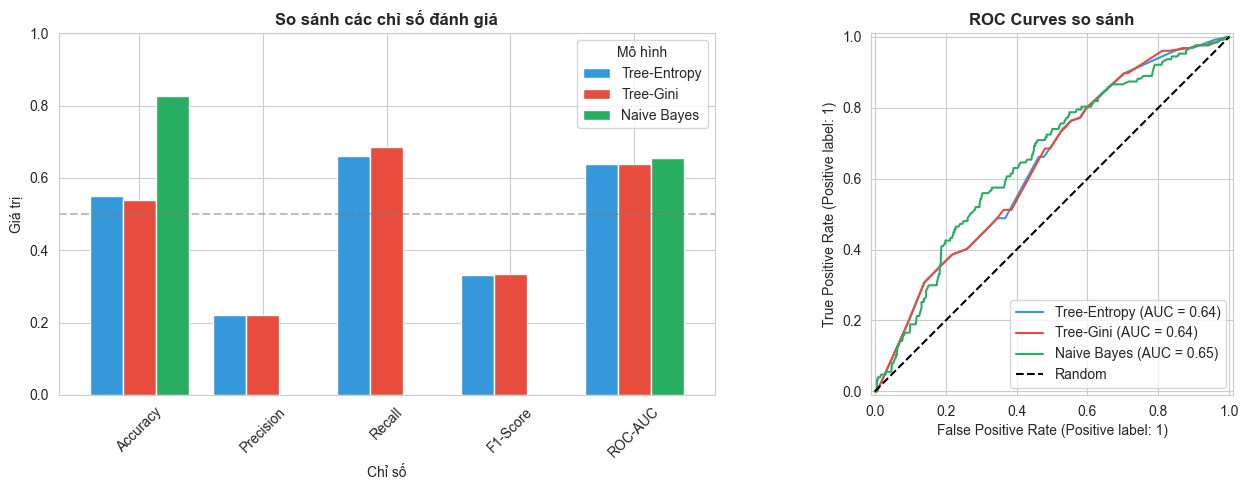

In [9]:
# Bảng so sánh các chỉ số
comparison = pd.DataFrame({
    "Tree-Entropy": {
        "Accuracy": tree_results["entropy"]["accuracy"],
        "Precision": tree_results["entropy"]["precision"],
        "Recall": tree_results["entropy"]["recall"],
        "F1-Score": tree_results["entropy"]["f1"],
        "ROC-AUC": tree_results["entropy"]["auc"]
    },
    "Tree-Gini": {
        "Accuracy": tree_results["gini"]["accuracy"],
        "Precision": tree_results["gini"]["precision"],
        "Recall": tree_results["gini"]["recall"],
        "F1-Score": tree_results["gini"]["f1"],
        "ROC-AUC": tree_results["gini"]["auc"]
    },
    "Naive Bayes": {
        "Accuracy": nb_results["accuracy"],
        "Precision": nb_results["precision"],
        "Recall": nb_results["recall"],
        "F1-Score": nb_results["f1"],
        "ROC-AUC": nb_results["auc"]
    }
})

print("="*60)
print("BẢNG SO SÁNH CÁC MÔ HÌNH")
print("="*60)
print(comparison.round(4).to_string())

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart so sánh metrics
ax1 = axes[0]
comparison.plot(kind='bar', ax=ax1, width=0.8, edgecolor='white', color=['#3498db', '#e74c3c', '#27ae60'])
ax1.set_title("So sánh các chỉ số đánh giá", fontsize=12, fontweight='bold')
ax1.set_xlabel("Chỉ số")
ax1.set_ylabel("Giá trị")
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title="Mô hình")
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# ROC Curves
ax2 = axes[1]
RocCurveDisplay.from_estimator(tree_results["entropy"]["pipe"], X_test, y_test, name="Tree-Entropy", ax=ax2, color='#3498db')
RocCurveDisplay.from_estimator(tree_results["gini"]["pipe"], X_test, y_test, name="Tree-Gini", ax=ax2, color='#e74c3c')
RocCurveDisplay.from_estimator(nb_results["pipe"], X_test, y_test, name="Naive Bayes", ax=ax2, color='#27ae60')
ax2.plot([0, 1], [0, 1], 'k--', label='Random')
ax2.set_title("ROC Curves so sánh", fontsize=12, fontweight='bold')
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

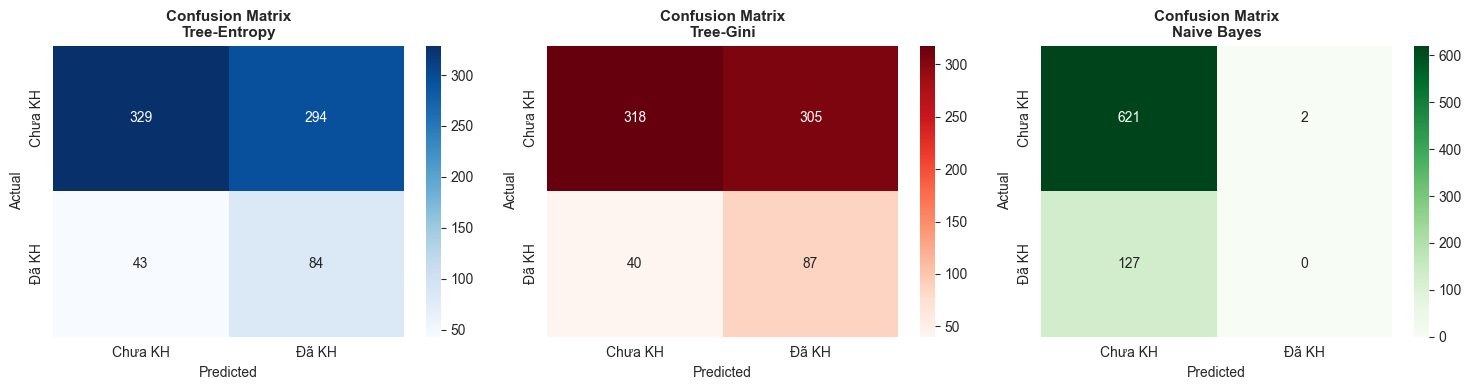

In [10]:
# Vẽ Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cms = {
    "Tree-Entropy": tree_results["entropy"]["cm"],
    "Tree-Gini": tree_results["gini"]["cm"],
    "Naive Bayes": nb_results["cm"]
}
cmaps = ['Blues', 'Reds', 'Greens']

for idx, (name, cm) in enumerate(cms.items()):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmaps[idx],
                xticklabels=["Chưa KH", "Đã KH"],
                yticklabels=["Chưa KH", "Đã KH"], ax=ax)
    ax.set_title(f"Confusion Matrix\n{name}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 8. Dự đoán cho Personas

Tạo các personas mẫu để kiểm tra khả năng dự đoán của mô hình.

In [11]:
# Tạo các personas mẫu
personas = pd.DataFrame({
    "age_group": ["25-29", "25-29", "30-35", "18-24", "30-35"],
    "sex": ["Nữ", "Nam", "Nữ", "Nữ", "Nam"],
    "region": ["Nam", "Bắc", "Bắc", "Trung", "Nam"],
    "urban_rural": ["Đô thị", "Đô thị", "Nông thôn", "Đô thị", "Nông thôn"],
    "education": ["ĐH", "ĐH", "≤THPT", ">ĐH", "≤THPT"],
    "income_level": ["mid", "mid", "low", "high", "low"],
    "has_child": [0, 0, 1, 0, 1]
})

print("="*60)
print("THÔNG TIN PERSONAS")
print("="*60)
print(personas.to_string())

# Dự đoán bằng Naive Bayes
print("\n" + "="*60)
print("DỰ ĐOÁN XÁC SUẤT KẾT HÔN - NAIVE BAYES")
print("="*60)
proba_nb = pipe_nb.predict_proba(personas)[:, 1]
personas_nb = personas.copy()
personas_nb["P_married_NB"] = proba_nb
print(personas_nb[["age_group", "sex", "region", "urban_rural", "education", "P_married_NB"]].to_string())

# Dự đoán bằng Decision Tree (entropy)
print("\n" + "="*60)
print("DỰ ĐOÁN XÁC SUẤT KẾT HÔN - DECISION TREE (ENTROPY)")
print("="*60)
proba_tree = tree_results["entropy"]["pipe"].predict_proba(personas)[:, 1]
personas_tree = personas.copy()
personas_tree["P_married_Tree"] = proba_tree
print(personas_tree[["age_group", "sex", "region", "urban_rural", "education", "P_married_Tree"]].to_string())

# So sánh
print("\n" + "="*60)
print("SO SÁNH DỰ ĐOÁN")
print("="*60)
comparison_personas = personas.copy()
comparison_personas["P_NaiveBayes"] = proba_nb.round(4)
comparison_personas["P_DecisionTree"] = proba_tree.round(4)
comparison_personas["Chênh lệch"] = (proba_nb - proba_tree).round(4)
print(comparison_personas[["age_group", "urban_rural", "education", "P_NaiveBayes", "P_DecisionTree", "Chênh lệch"]].to_string())

THÔNG TIN PERSONAS
  age_group  sex region urban_rural education income_level  has_child
0     25-29   Nữ    Nam      Đô thị        ĐH          mid          0
1     25-29  Nam    Bắc      Đô thị        ĐH          mid          0
2     30-35   Nữ    Bắc   Nông thôn     ≤THPT          low          1
3     18-24   Nữ  Trung      Đô thị       >ĐH         high          0
4     30-35  Nam    Nam   Nông thôn     ≤THPT          low          1

DỰ ĐOÁN XÁC SUẤT KẾT HÔN - NAIVE BAYES
  age_group  sex region urban_rural education  P_married_NB
0     25-29   Nữ    Nam      Đô thị        ĐH      0.118005
1     25-29  Nam    Bắc      Đô thị        ĐH      0.133841
2     30-35   Nữ    Bắc   Nông thôn     ≤THPT      0.410592
3     18-24   Nữ  Trung      Đô thị       >ĐH      0.040564
4     30-35  Nam    Nam   Nông thôn     ≤THPT      0.418525

DỰ ĐOÁN XÁC SUẤT KẾT HÔN - DECISION TREE (ENTROPY)
  age_group  sex region urban_rural education  P_married_Tree
0     25-29   Nữ    Nam      Đô thị        ĐH  

## 9. Kết luận & Lưu kết quả

### Insight chính:
- **Biến quan trọng nhất**: `age_group`, `urban_rural`, `education`
- **Nhóm có tỷ lệ kết hôn thấp**: 18-24, đô thị, học vấn ĐH/>ĐH
- **Nhóm có tỷ lệ kết hôn cao**: 30-35, nông thôn, học vấn ≤THPT

### So sánh mô hình:
- **Decision Tree**: Cho luật IF-THEN rõ ràng, dễ giải thích
- **Naive Bayes**: Nhanh, cho posterior trực tiếp

In [12]:
# Lưu dữ liệu và kết quả
import os
import joblib

# Tạo thư mục
os.makedirs("../data", exist_ok=True)
os.makedirs("../models", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

# Lưu dữ liệu
df.to_csv("../data/marriage_data.csv", index=False, encoding="utf-8-sig")
print("Đã lưu: ../data/marriage_data.csv")

# Lưu mô hình
joblib.dump(tree_results["entropy"]["pipe"], "../models/pipe_entropy.pkl")
joblib.dump(tree_results["gini"]["pipe"], "../models/pipe_gini.pkl")
joblib.dump(pipe_nb, "../models/pipe_naive_bayes.pkl")
print("Đã lưu các mô hình vào thư mục ../models/")

# Lưu bảng so sánh
comparison.round(4).to_csv("../outputs/metrics_comparison.csv")
print("Đã lưu: ../outputs/metrics_comparison.csv")

print("\nHOÀN THÀNH!")

Đã lưu: ../data/marriage_data.csv
Đã lưu các mô hình vào thư mục ../models/
Đã lưu: ../outputs/metrics_comparison.csv

HOÀN THÀNH!
